In [1]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [3]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [4]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [6]:
path = 'https://bit.ly/irisdata_csv'
data = pd.read_csv(path)
data.head()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
plt.show()

In [8]:
target = 'Species'
x = data.drop(target, axis = 1)
y = data.loc[:, target]


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(type(y))


<class 'numpy.ndarray'>


In [11]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state=20)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# 데이터 로더
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [ ]:
#입출력을 잘 맞추면 됨
n_feature = x.shape[1]   #입력층의 개수(column의 개수 , 4개)
n_class = len(le.classes_)    #출력층의 개수, 레이블의 클래스수  3개


# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, n_class),   #(4,3)
            ).to(device)


In [15]:
print(le.classes_)
y_orig = le.inverse_transform(y)


['setosa' 'versicolor' 'virginica']


In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.1)


In [17]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 1.037253, val loss : 0.951362
Epoch 2, train loss : 0.834676, val loss : 0.863678
Epoch 3, train loss : 0.725561, val loss : 0.720486
Epoch 4, train loss : 0.576859, val loss : 0.629378
Epoch 5, train loss : 0.543388, val loss : 0.585759
Epoch 6, train loss : 0.493994, val loss : 0.556365
Epoch 7, train loss : 0.407666, val loss : 0.543554
Epoch 8, train loss : 0.406281, val loss : 0.542333
Epoch 9, train loss : 0.378512, val loss : 0.516096
Epoch 10, train loss : 0.368902, val loss : 0.484092
Epoch 11, train loss : 0.354193, val loss : 0.466002
Epoch 12, train loss : 0.353555, val loss : 0.455360
Epoch 13, train loss : 0.331084, val loss : 0.445928
Epoch 14, train loss : 0.325590, val loss : 0.444599
Epoch 15, train loss : 0.358598, val loss : 0.449225
Epoch 16, train loss : 0.308852, val loss : 0.423391
Epoch 17, train loss : 0.303379, val loss : 0.417232
Epoch 18, train loss : 0.303454, val loss : 0.424609
Epoch 19, train loss : 0.283343, val loss : 0.438084
Ep

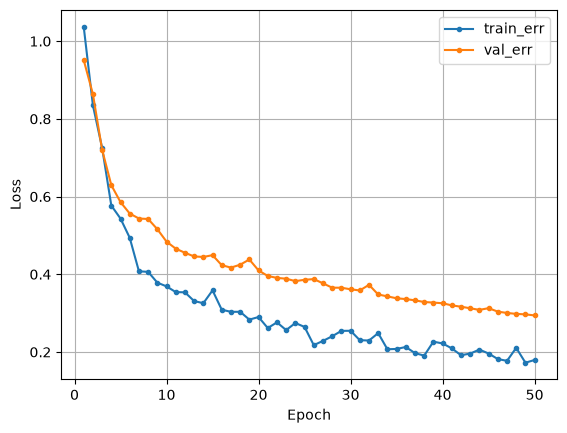

In [ ]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [20]:
from torchvision import datasets
from torchvision.transforms import ToTensor


train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor() )
test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor() )


In [21]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [22]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [ ]:
#레이블  
train_dataset.targets.shape

torch.Size([60000])

In [24]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

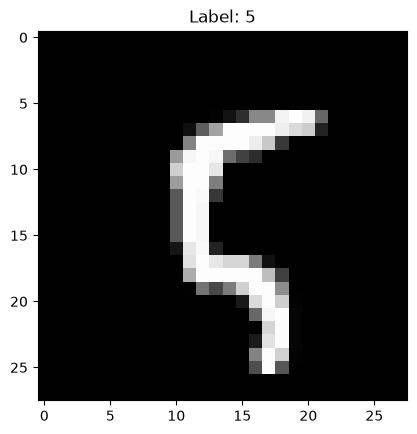

In [30]:
#한장 이미지 출력
n = 100
image, label = train_dataset.data[n], train_dataset.targets[n]

#이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [ ]:
batch_size = 64   #한번에 이미지 64장을 집어넣어 학습함
train_loader = DataLoader(train_dataset, batch_size=batch_size)


In [33]:
#val 데이터: epoch마다 학습이 잘되고 있는 평가하는 데이터
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]
x_val.shape, y_val.shape


(torch.Size([5000, 28, 28]), torch.Size([5000]))

In [34]:
# MinMax
x_val = x_val / 255
x_test = x_test / 255


In [35]:
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)
print(x_val.shape, x_test.shape)


torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


In [37]:
n_feature = 28 * 28  #입력층
n_class = 10  #출력층


# 모델 구조 설계
model = nn.Sequential(nn.Flatten(), #1차원 변경   28 * 28 => 784 (1차원)으로 변경
    nn.Linear(n_feature, n_class)  #softmax는 없지만 밑에 crosstentropy는 있다
    ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [38]:
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.549056, val loss : 0.428744
Epoch 2, train loss : 0.328947, val loss : 0.378865
Epoch 3, train loss : 0.299971, val loss : 0.360506
Epoch 4, train loss : 0.286126, val loss : 0.351408
Epoch 5, train loss : 0.277611, val loss : 0.346199
Epoch 6, train loss : 0.271661, val loss : 0.342937
Epoch 7, train loss : 0.267173, val loss : 0.340772
Epoch 8, train loss : 0.263613, val loss : 0.339283
Epoch 9, train loss : 0.260689, val loss : 0.338240
Epoch 10, train loss : 0.258226, val loss : 0.337508


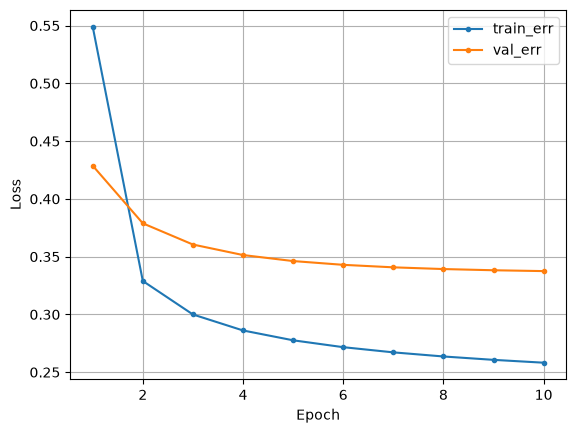

In [39]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)


In [40]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
print(pred[:5])


tensor([[1.2247e-03, 7.7533e-06, 8.5370e-04, 6.1894e-01, 3.9669e-04, 3.7420e-01,
         3.1267e-06, 1.0840e-05, 3.6824e-03, 6.8736e-04],
        [3.0873e-04, 7.4570e-08, 3.0999e-03, 8.7779e-03, 2.8764e-01, 4.1985e-03,
         3.4977e-04, 3.8065e-03, 2.2293e-01, 4.6889e-01],
        [7.5861e-07, 2.8499e-11, 1.4371e-07, 1.5145e-06, 5.3368e-03, 1.3059e-06,
         1.1297e-07, 8.1956e-04, 2.3880e-03, 9.9145e-01],
        [2.3445e-07, 1.2026e-09, 9.7383e-07, 5.3593e-06, 2.7219e-07, 2.7782e-04,
         9.1406e-09, 2.3099e-08, 9.9925e-01, 4.6051e-04],
        [7.6917e-05, 7.5513e-12, 3.9902e-06, 1.1594e-07, 9.9839e-01, 2.5521e-05,
         6.1331e-05, 3.0048e-05, 1.5412e-04, 1.2560e-03]], device='cuda:0')


In [41]:
pred = np.argmax(pred.cpu().numpy(), axis = 1)
print(pred[:5])


[3 9 9 8 4]


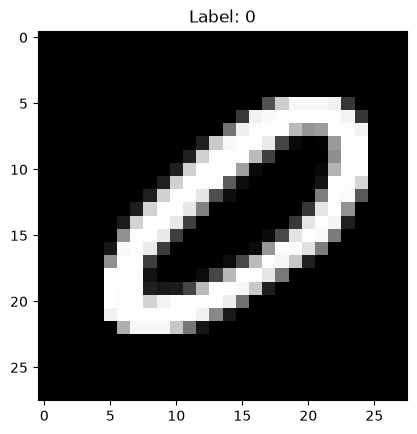

In [51]:
#x_test
#[5000 -> 3  5001 -> 9  5002 ]
n=8
image,label = test_dataset.data[5000+n], test_dataset.targets[5000+n]
plt.imshow(image, cmap='grey')
plt.title(f'Label: {label}')
plt.show()

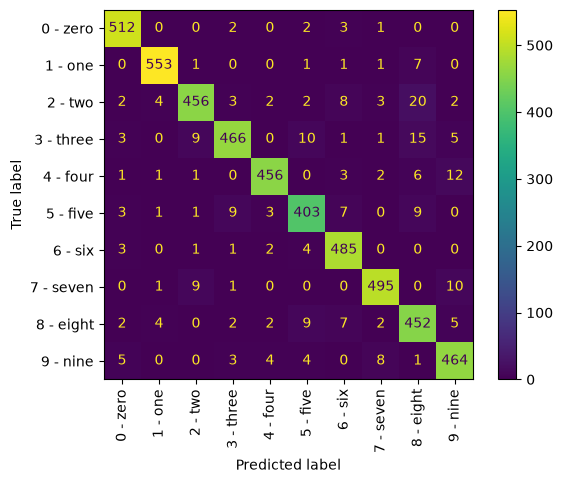

In [52]:
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()


In [53]:
n_feature = 28 * 28
n_class = 10
# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 20), nn.ReLU(),
            nn.Linear(20, n_class)
            ).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [54]:
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.538045, val loss : 0.383127
Epoch 2, train loss : 0.280760, val loss : 0.327655
Epoch 3, train loss : 0.243849, val loss : 0.295132
Epoch 4, train loss : 0.216921, val loss : 0.268159
Epoch 5, train loss : 0.196307, val loss : 0.249749
Epoch 6, train loss : 0.180710, val loss : 0.235690
Epoch 7, train loss : 0.168512, val loss : 0.225382
Epoch 8, train loss : 0.158923, val loss : 0.217909
Epoch 9, train loss : 0.150998, val loss : 0.212107
Epoch 10, train loss : 0.144288, val loss : 0.208126


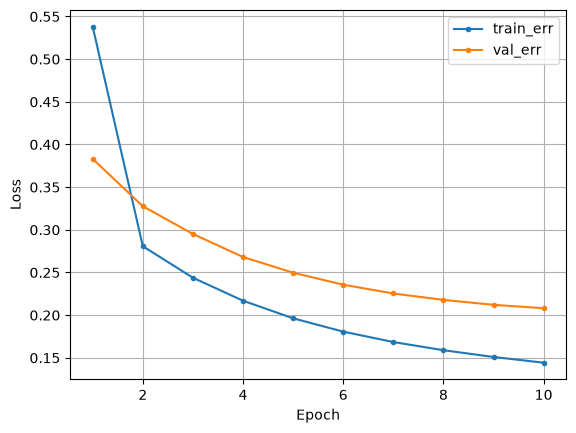

In [55]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)
